In [88]:
%conda install -y pandas matplotlib seaborn scikit-learn

Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data loading

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- File 1: Multi-station 2016-2020 ---
header_row = pd.read_csv('data/AirQualityDataDaily2016_2020.csv', skiprows=3, nrows=1, header=None)
station_names = header_row.iloc[0].tolist()

raw1 = pd.read_csv('data/AirQualityDataDaily2016_2020.csv', skiprows=11, header=None)

records = []
col_idx = 1
station_idx = 1
while col_idx < raw1.shape[1] - 1:
    sname = station_names[station_idx] if station_idx < len(station_names) else f'Station_{col_idx}'
    if pd.isna(sname) or str(sname).strip() == '':
        col_idx += 2; station_idx += 2; continue
    values = raw1.iloc[:, col_idx]
    status = raw1.iloc[:, col_idx + 1] if col_idx + 1 < raw1.shape[1] else [None]*len(raw1)
    for d, v, s in zip(raw1.iloc[:, 0], values, status):
        records.append({'date': d, 'station': str(sname).strip(), 'pm25_raw': v, 'status_raw': s})
    col_idx += 2; station_idx += 2

df1 = pd.DataFrame(records)

# --- File 2: Single station 2020-2025 ---
df2 = pd.read_csv('data/AirQualityDataDaily2021_2025.csv', skiprows=11, header=None,
                  names=['date', 'pm25_raw', 'status_raw'])
df2['station'] = 'London Marylebone Road'
df2 = df2[['date', 'station', 'pm25_raw', 'status_raw']]

# Combine
df = pd.concat([df1, df2], ignore_index=True)

print(f'Raw combined shape (before any parsing): {df.shape}')
df.head(10)


Raw combined shape (before any parsing): (20110, 4)


,date,station,pm25_raw,status_raw
0,2016-01-01,Auchencorth Moss,2.886,V ugm-3 (GRAV EMFAB)
1,2016-01-02,Auchencorth Moss,1.12,V ugm-3 (GRAV EMFAB)
2,2016-01-03,Auchencorth Moss,0.56,V ugm-3 (GRAV EMFAB)
3,2016-01-04,Auchencorth Moss,1.983,V ugm-3 (GRAV EMFAB)
4,2016-01-05,Auchencorth Moss,2.372,V ugm-3 (GRAV EMFAB)
5,2016-01-06,Auchencorth Moss,2.157,V ugm-3 (GRAV EMFAB)
6,2016-01-07,Auchencorth Moss,0.259,V ugm-3 (GRAV EMFAB)
7,2016-01-08,Auchencorth Moss,2.33,V ugm-3 (GRAV EMFAB)
8,2016-01-09,Auchencorth Moss,2.417,V ugm-3 (GRAV EMFAB)
9,2016-01-10,Auchencorth Moss,-0.086,V ugm-3 (GRAV EMFAB)


#### Standardize date columns

In [91]:
#standarize date columns
df['date'] = pd.to_datetime(df['date'], errors='coerce')
print(f'After parsing dates, shape: {df.shape}')
print(df['date'].head())

After parsing dates, shape: (20110, 4)
0   2016-01-01
1   2016-01-02
2   2016-01-03
3   2016-01-04
4   2016-01-05
Name: date, dtype: datetime64[us]


#### Parse pm25_raw into numeric, errors as NaN

In [92]:
#Parse pm25_raw into numeric, errors as NaN
# 'No data' strings and blank cells become NaN here.
df['pm25_raw'] = pd.to_numeric(df['pm25_raw'], errors='coerce')
print(f'After parsing pm25_raw, shape: {df.shape}')
print(df['pm25_raw'].head())

After parsing pm25_raw, shape: (20110, 4)
0    2.886
1    1.120
2    0.560
3    1.983
4    2.372
Name: pm25_raw, dtype: float64


#### Value counts of 'status_raw'

In [93]:
#value counts of 'status_raw'
print(df['status_raw'].value_counts(dropna=False))

status_raw
NaN                     10542
V ugm-3 (GRAV EMFAB)     9568
Name: count, dtype: int64


In [94]:
# fill actual NaN values with 'Unverified'
df['status_raw'] = df['status_raw'].fillna('Unverified')
print(df['status_raw'].value_counts(dropna=False))

status_raw
Unverified              10542
V ugm-3 (GRAV EMFAB)     9568
Name: count, dtype: int64


#### Impossible PM2.5 values

In [95]:
#anything negative is impossible for PM2.5, drop those rows
# Use ~(< 0) instead of (>= 0) so NaN rows survive this filter
# (NaN >= 0 is False, NaN < 0 is also False -> ~False is True -> kept).
negative_pm25_count = (df['pm25_raw'] < 0).sum()
print(f'Number of rows with negative PM2.5 values: {negative_pm25_count}')
df = df[~(df['pm25_raw'] < 0)]
print(f'After dropping negative PM2.5 values, shape: {df.shape}')

Number of rows with negative PM2.5 values: 7
After dropping negative PM2.5 values, shape: (20103, 4)


#### How many stations?

In [96]:
#how many stations?
print(f'Unique stations: {df["station"].nunique()}')
print(f'Station names: {df["station"].unique()}')

Unique stations: 10
Station names: <StringArray>
[       'Auchencorth Moss',             'Bournemouth',
   'Brighton Preston Park',  'Chilbolton Observatory',
               'Inverness',  'London Marylebone Road',
    'London N. Kensington',      'London Westminster',
 'Northampton Kingsthorpe',                 'Wrexham']
Length: 10, dtype: str


#### Assign region to each station

In [97]:
# Group stations into UK regions so downstream code can enforce geographic
# diversity (national rule) and report rural-vs-urban patterns. Defined once
# here and used everywhere — do not redefine this dict in later cells.
STATION_REGION = {
    'Auchencorth Moss':        'Scotland',
    'Inverness':               'Scotland',
    'Wrexham':                 'Wales',
    'Northampton Kingsthorpe': 'Midlands',
    'Bournemouth':             'South',
    'Brighton Preston Park':   'South',
    'Chilbolton Observatory':  'South',
    'London Marylebone Road':  'London',
    'London N. Kensington':    'London',
    'London Westminster':      'London',
}
df['region'] = df['station'].map(STATION_REGION)

# Sanity check: every station should have a region
unmapped = df.loc[df['region'].isna(), 'station'].unique()
print(f'Stations missing a region mapping: {list(unmapped) if len(unmapped) else "none"}')
print('\nStations per region:')
print(df.groupby('region')['station'].nunique().sort_values(ascending=False))

Stations missing a region mapping: none

Stations per region:
region
London      3
South       3
Scotland    2
Midlands    1
Wales       1
Name: station, dtype: int64


#### How many NA's?

Number of NA values in pm25_raw: 11150


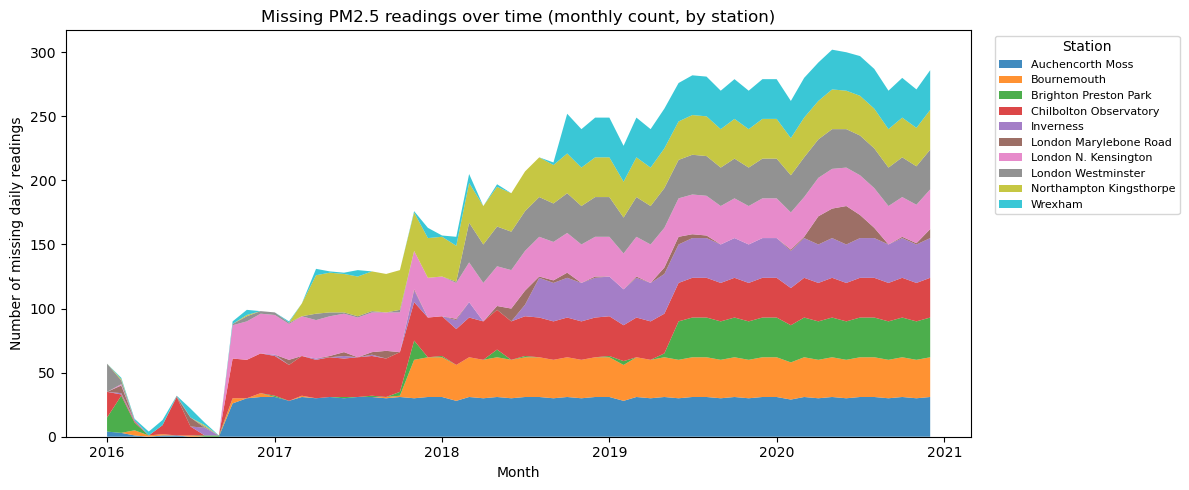

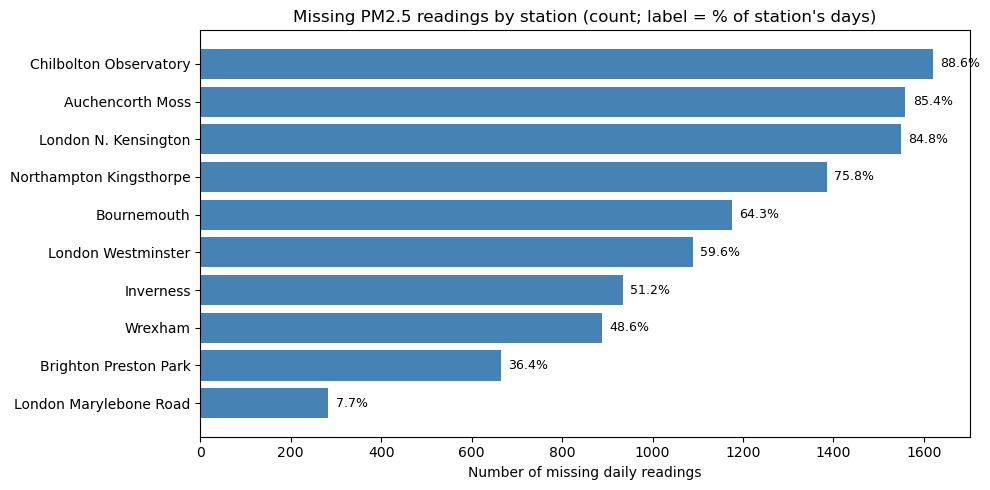


Worst stations by NA count:
                         na_count  pct_missing
station                                       
Chilbolton Observatory       1620         88.6
Auchencorth Moss             1559         85.4
London N. Kensington         1550         84.8
Northampton Kingsthorpe      1385         75.8
Bournemouth                  1175         64.3
London Westminster           1089         59.6
Inverness                     935         51.2
Wrexham                       889         48.6
Brighton Preston Park         665         36.4
London Marylebone Road        283          7.7

After dropping NA pm25_raw rows, shape: (8953, 5)


In [98]:
#how many NA's in pm25_raw? (these come from 'No data' / blank cells in the source CSVs)
na_pm25_count = df['pm25_raw'].isna().sum()
print(f'Number of NA values in pm25_raw: {na_pm25_count}')

# --- Plot 1: time span of NA's (monthly count, stacked by station) ---
na_rows = df[df['pm25_raw'].isna()].copy()
# station may be a pandas StringArray; cast to plain object so groupby/unstack
# produce a numeric-dtype matrix that plot(kind='area') accepts.
na_rows['station'] = na_rows['station'].astype(str)
na_rows['month'] = na_rows['date'].dt.to_period('M').dt.to_timestamp()
na_by_month_station = (na_rows.groupby(['month', 'station']).size()
                              .unstack(fill_value=0)
                              .sort_index()
                              .astype('int64'))

fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(na_by_month_station.index,
             na_by_month_station.T.values,
             labels=na_by_month_station.columns,
             alpha=0.85)
ax.set_title('Missing PM2.5 readings over time (monthly count, by station)')
ax.set_xlabel('Month')
ax.set_ylabel('Number of missing daily readings')
ax.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# --- Plot 2: worst stations (count + % of that station's days that are missing) ---
station_total = df.groupby('station').size()
station_na    = na_rows.groupby('station').size().reindex(station_total.index, fill_value=0)
station_pct   = (station_na / station_total * 100).round(1)

worst = (pd.DataFrame({'na_count': station_na, 'pct_missing': station_pct})
           .sort_values('na_count', ascending=True))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(worst.index.astype(str), worst['na_count'].astype(int), color='steelblue')
for bar, pct in zip(bars, worst['pct_missing']):
    ax.text(bar.get_width() + max(worst['na_count']) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{pct}%', va='center', fontsize=9)
ax.set_title("Missing PM2.5 readings by station (count; label = % of station's days)")
ax.set_xlabel('Number of missing daily readings')
plt.tight_layout()
plt.show()

print('\nWorst stations by NA count:')
print(worst.sort_values('na_count', ascending=False))

# Drop NA rows now that we've inspected them
df = df.dropna(subset=['pm25_raw'])
print(f'\nAfter dropping NA pm25_raw rows, shape: {df.shape}')

#### Outliers in PM2.5 values?

Global summary:
count    8953.00
mean        8.57
std         6.86
min         0.00
50%         6.60
90%        16.30
95%        21.60
99%        35.39
99.9%      59.80
max        92.22
Name: pm25_raw, dtype: float64

Readings above hard cap (250 ugm-3): 0

Per-station outlier summary (Q3 + 3*IQR rule):
                            n  median    p99    max  iqr_upper  n_outliers  \
station                                                                      
London Marylebone Road   3375    8.56  38.43  92.22      31.30          74   
Brighton Preston Park    1163    6.96  37.36  53.96      27.57          43   
Bournemouth               653    5.38  29.82  46.25      21.11          33   
London Westminster        739    7.00  42.61  79.63      28.52          24   
Wrexham                   939    5.10  29.30  49.09      24.36          24   
Northampton Kingsthorpe   442    5.02  37.01  48.71      25.23          20   
Inverness                 890    3.75  17.70  30.94      13.55         

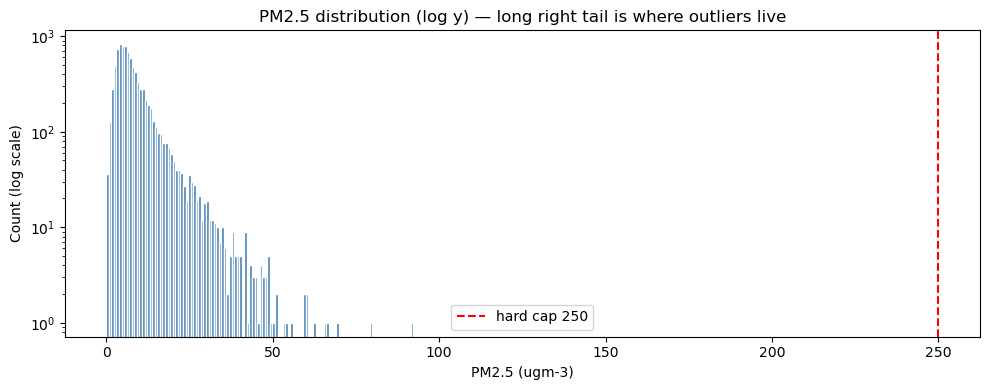

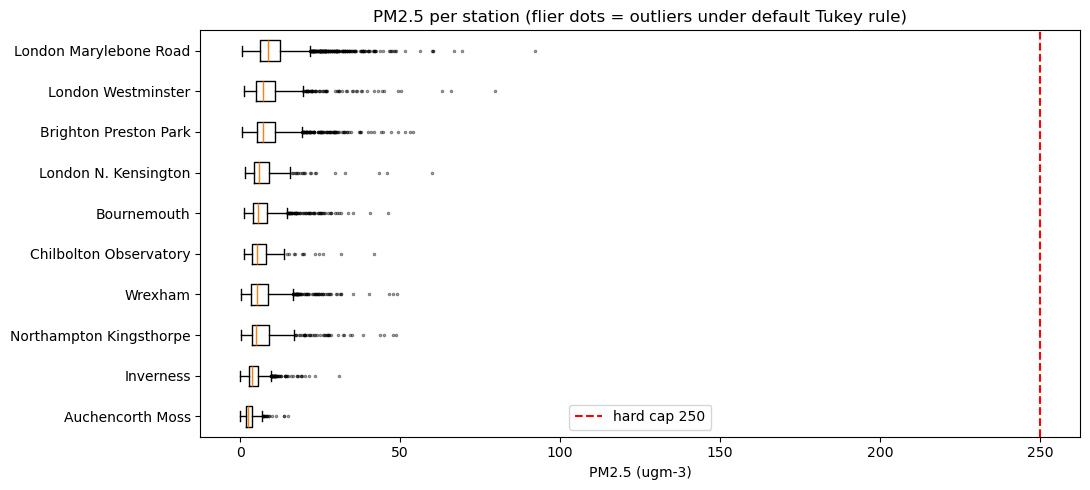

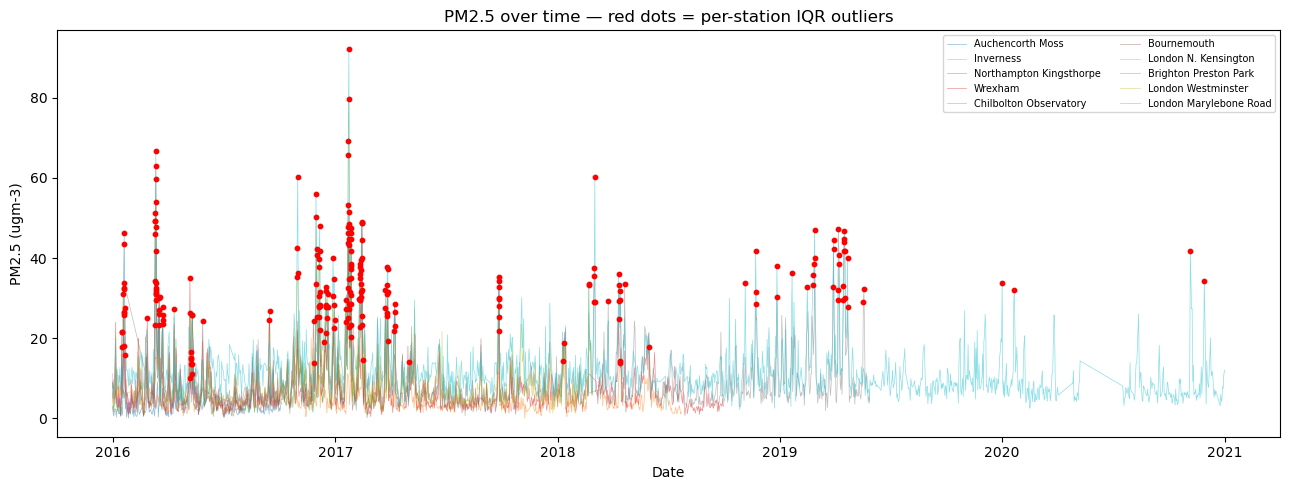

In [ ]:
# --- Outlier inspection (no rows dropped here — just surface them) ---
# PM2.5 baselines differ a lot by site type (rural Auchencorth ~3 ugm-3 vs urban
# London Marylebone ~15 ugm-3), so a single global threshold is misleading.
# We check three lenses: hard cap, per-station IQR, and the top-N table.

PM25_HARD_CAP = 250  # Research actual limit?

print('Global summary:')
print(df['pm25_raw'].describe(percentiles=[.5, .9, .95, .99, .999]).round(2))

# 1) Hard cap
hard = df[df['pm25_raw'] > PM25_HARD_CAP]
print(f'\nReadings above hard cap ({PM25_HARD_CAP} ugm-3): {len(hard)}')
if len(hard):
    print(hard.sort_values('pm25_raw', ascending=False).head(10).to_string(index=False))

# 2) Per-station IQR rule (Tukey: > Q3 + 3*IQR is a "far" outlier)
# Use transform so the bound is broadcast back per row without losing the
# 'station' column (which groupby().apply() drops in newer pandas versions).
grouped = df.groupby('station')['pm25_raw']
q1 = grouped.transform(lambda s: s.quantile(0.25))
q3 = grouped.transform(lambda s: s.quantile(0.75))
iqr = q3 - q1
flagged = df.copy()
flagged['iqr_upper']  = q3 + 3 * iqr
flagged['is_outlier'] = flagged['pm25_raw'] > flagged['iqr_upper']

per_station = (flagged.groupby('station')
                      .agg(n=('pm25_raw', 'size'),
                           median=('pm25_raw', 'median'),
                           p99=('pm25_raw', lambda s: s.quantile(0.99)),
                           max=('pm25_raw', 'max'),
                           iqr_upper=('iqr_upper', 'first'),
                           n_outliers=('is_outlier', 'sum'))
                      .assign(pct_outliers=lambda d: (d['n_outliers'] / d['n'] * 100).round(2))
                      .sort_values('n_outliers', ascending=False))
print('\nPer-station outlier summary (Q3 + 3*IQR rule):')
print(per_station.round(2))

# 3) Top 20 highest readings (with status + station context)
print('\nTop 20 highest PM2.5 readings:')
print(df.nlargest(20, 'pm25_raw')[['date', 'station', 'pm25_raw', 'status_raw']]
        .to_string(index=False))

# --- Plot 1: distribution (log y, so the long tail is visible) ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['pm25_raw'].dropna(), bins=120, color='steelblue', edgecolor='white')
ax.set_yscale('log')
ax.axvline(PM25_HARD_CAP, color='red', linestyle='--', label=f'hard cap {PM25_HARD_CAP}')
ax.set_title('PM2.5 distribution (log y) — long right tail is where outliers live')
ax.set_xlabel('PM2.5 (ugm-3)')
ax.set_ylabel('Count (log scale)')
ax.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: per-station boxplot, sorted by median ---
order = (df.groupby('station')['pm25_raw'].median()
           .sort_values().index.astype(str).tolist())
data_by_station = [df.loc[df['station'].astype(str) == s, 'pm25_raw'].values for s in order]

fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(data_by_station, labels=order, vert=False, showfliers=True,
           flierprops=dict(marker='.', markersize=3, alpha=0.5))
ax.axvline(PM25_HARD_CAP, color='red', linestyle='--', label=f'hard cap {PM25_HARD_CAP}')
ax.set_title('PM2.5 per station (flier dots = outliers under default Tukey rule)')
ax.set_xlabel('PM2.5 (ugm-3)')
ax.legend()
plt.tight_layout()
plt.show()

# --- Plot 3: time series with per-station outliers highlighted ---
fig, ax = plt.subplots(figsize=(13, 5))
for s in order:
    sub = flagged[flagged['station'].astype(str) == s].sort_values('date')
    ax.plot(sub['date'], sub['pm25_raw'], linewidth=0.5, alpha=0.5, label=s)
    out = sub[sub['is_outlier']]
    ax.scatter(out['date'], out['pm25_raw'], s=10, color='red', zorder=3)
ax.set_title('PM2.5 over time — red dots = per-station IQR outliers')
ax.set_xlabel('Date'); ax.set_ylabel('PM2.5 (ugm-3)')
ax.legend(fontsize=7, ncol=2, loc='upper right')
plt.tight_layout()
plt.show()

AI Generated (check factualness):

Plot 1 — Distribution (log y)
A histogram of every PM2.5 reading, with a log-scale y-axis so even single rare readings stay visible instead of being swallowed by the bulk near zero. Anything to the right of the red 250 µg/m³ line is implausibly high for the UK and worth a closer look.

Plot 2 — Per-station boxplot
Each row shows one station's spread, sorted by median, so you can see at a glance that rural sites (Auchencorth, Inverness) sit far below the London sites. The dots past the whiskers are each station's own outliers, proving a global threshold is wrong, because 20 µg/m³ is extreme for Auchencorth but routine for Marylebone.

Plot 3 — Time series with outliers highlighted
Every station's daily readings plotted over time, with red dots marking that station's per-station IQR outliers. If red dots cluster on the same dates across multiple stations they're likely real pollution events (dust, fireworks, wildfire); if they're scattered on one station only, they're more likely sensor faults.
darker bands = stations clustered together (similar readings), fainter strands = a station diverging from the pack.

#### Duplicate checks

In [100]:
#duplicates are when the same station has multiple readings for the same date (should be 1 reading per station per day)
duplicates = df.groupby(['date', 'station']).size()
duplicate_rows = duplicates[duplicates > 1]
print(f'\nNumber of duplicate date-station pairs: {len(duplicate_rows)}')
if len(duplicate_rows):
    print('Duplicate date-station pairs (date, station, count):')
    print(duplicate_rows.reset_index(name='count').to_string(index=False))  


Number of duplicate date-station pairs: 0


#### Longest consecutive-day reading streaks

In [101]:
# For time-series modelling we need contiguous daily sequences.
# Report longest gap-free run (a) per station and (b) for the national-rule
# series (a date "counts" only if >= 3 stations from >= 2 regions report).

def longest_run(dates: pd.Series) -> tuple[int, pd.Timestamp, pd.Timestamp]:
    """Return (length, start, end) of the longest run of consecutive daily dates."""
    if dates.empty:
        return 0, pd.NaT, pd.NaT
    d = pd.to_datetime(pd.Series(dates).dt.normalize().unique())
    d = pd.Series(d).sort_values().reset_index(drop=True)
    gap   = d.diff().dt.days.fillna(1)
    group = (gap != 1).cumsum()
    runs  = d.groupby(group).agg(['min', 'max', 'count'])
    best  = runs.loc[runs['count'].idxmax()]
    return int(best['count']), best['min'], best['max']

# --- Per station ---
rows = []
for station, sub in df.groupby('station'):
    n, start, end = longest_run(sub['date'])
    rows.append({'station': station, 'longest_run_days': n,
                 'start': start.date(), 'end': end.date()})
per_station_runs = (pd.DataFrame(rows)
                      .sort_values('longest_run_days', ascending=False)
                      .reset_index(drop=True))
print('Longest consecutive-day streak per station:')
print(per_station_runs.to_string(index=False))

# --- National rule: >= 3 stations from >= 2 distinct regions on the same day ---
# (uses the 'region' column assigned earlier — no local redefinition here)
per_date = df.groupby('date').agg(n_stations=('station', 'nunique'),
                                  n_regions=('region', 'nunique'))
national_dates = per_date[(per_date['n_stations'] >= 3) &
                          (per_date['n_regions']  >= 2)].index.to_series()
n, start, end = longest_run(national_dates)
print(f'\nNational rule (>=3 stations, >=2 regions):')
print(f'  longest gap-free run: {n} days  ({start.date()} -> {end.date()})')
print(f'  total qualifying days: {len(national_dates)}')

Longest consecutive-day streak per station:
                station  longest_run_days      start        end
   London N. Kensington               233 2016-02-16 2016-10-05
 London Marylebone Road               202 2016-07-19 2017-02-05
Northampton Kingsthorpe               187 2016-02-21 2016-08-25
  Brighton Preston Park               184 2018-07-31 2019-01-30
            Bournemouth               183 2017-03-08 2017-09-06
              Inverness               153 2016-03-02 2016-08-01
     London Westminster               137 2017-10-14 2018-02-27
                Wrexham               127 2017-07-25 2017-11-28
       Auchencorth Moss               111 2016-06-17 2016-10-05
 Chilbolton Observatory                85 2016-07-08 2016-09-30

National rule (>=3 stations, >=2 regions):
  longest gap-free run: 789 days  (2016-01-01 -> 2018-02-27)
  total qualifying days: 989


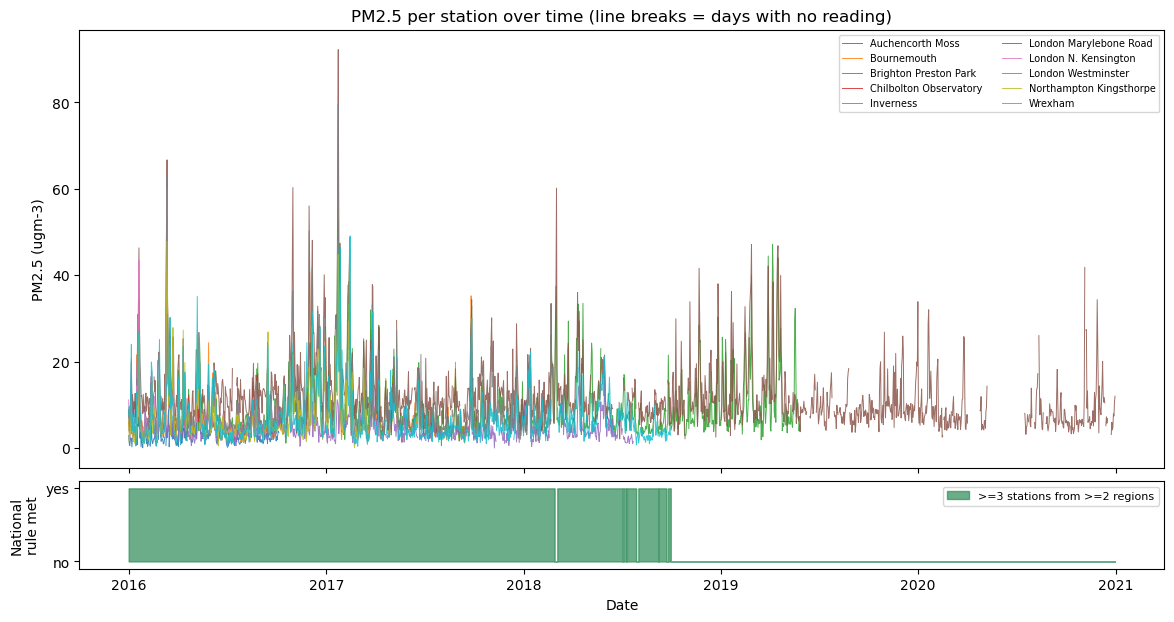

Rule satisfied on 989 of 1827 days (54.1%)


In [102]:
# --- Time series per station with gaps visible + national-rule indicator ---
# Reindex each station to the full daily date range so missing days become NaN
# and matplotlib draws a break (rather than connecting across the gap).
# Uses the 'region' column assigned earlier — no local redefinition here.

# Normalize date to midnight in case there are time components, then aggregate
# per (station, date) before set_index — defensive against any stray duplicates.
df_plot = df.copy()
df_plot['date'] = df_plot['date'].dt.normalize()

full_range = pd.date_range(df_plot['date'].min(), df_plot['date'].max(), freq='D')

# Dates that satisfy the national rule (>=3 stations from >=2 regions)
per_date = df_plot.groupby('date').agg(n_stations=('station', 'nunique'),
                                       n_regions=('region', 'nunique'))
rule_mask   = (per_date['n_stations'] >= 3) & (per_date['n_regions'] >= 2)
rule_series = rule_mask.reindex(full_range, fill_value=False)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(14, 7), sharex=True,
    gridspec_kw={'height_ratios': [5, 1], 'hspace': 0.05}
)

# Top: one line per station; aggregate per date first so reindex never sees dupes
stations = sorted(df_plot['station'].astype(str).unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(stations)))
for s, c in zip(stations, colors):
    sub = (df_plot[df_plot['station'].astype(str) == s]
             .groupby('date')['pm25_raw'].mean()
             .reindex(full_range))
    ax_top.plot(sub.index, sub.values, linewidth=0.7, alpha=0.85, color=c, label=s)

ax_top.set_ylabel('PM2.5 (ugm-3)')
ax_top.set_title('PM2.5 per station over time (line breaks = days with no reading)')
ax_top.legend(fontsize=7, ncol=2, loc='upper right')

# Bottom: rule indicator as a step fill (1 = rule met, 0 = not)
ax_bot.fill_between(full_range, 0, rule_series.astype(int).values,
                    step='mid', color='seagreen', alpha=0.7,
                    label='>=3 stations from >=2 regions')
ax_bot.set_ylim(-0.1, 1.1)
ax_bot.set_yticks([0, 1])
ax_bot.set_yticklabels(['no', 'yes'])
ax_bot.set_xlabel('Date')
ax_bot.set_ylabel('National\nrule met')
ax_bot.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

pct = rule_series.mean() * 100
print(f'Rule satisfied on {int(rule_series.sum())} of {len(rule_series)} days ({pct:.1f}%)')

#### Timestamp normalization

explain this

In [ ]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
#TODO: explain this

#### Train, validation, test split

Whats the best way to do this?